In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflixsshi/netflix_titles.csv
/kaggle/input/netflix-bkc/netflix_movies_detailed_up_to_2025.csv


In [ ]:
!pip install pandas numpy plotly scikit-learn nltk textblob

In [ ]:
# netflix_text_analysis_plotly.py
import os
import re
import math
import json
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from textblob import TextBlob
from wordcloud import WordCloud
import nltk
from collections import Counter, defaultdict

# nltk downloads (first run)
nltk.download('punkt')
nltk.download('stopwords')

STOPWORDS = set(nltk.corpus.stopwords.words('english'))

# -----------------------
# 0. Load data
# -----------------------
FN = '/kaggle/input/netflixsshi/netflix_titles.csv'  # change path if needed
df = pd.read_csv(FN)

# unify column names (tolerant)
df.columns = [c.strip() for c in df.columns]

# keep only rows with descriptions (you can keep empty, but NLP needs text)
df['description'] = df['description'].fillna('').astype(str)
df['listed_in'] = df['listed_in'].fillna('').astype(str)
df['title'] = df['title'].fillna('').astype(str)
df['show_id'] = df.get('show_id', df.index.astype(str))

# -----------------------
# 1. Text cleaning utilities
# -----------------------
def clean_text(text):
    text = str(text).lower()
    # basic cleaning
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = text.strip()
    return text

df['desc_clean'] = df['description'].apply(clean_text)

# small tokenization helper
def tokenize(text):
    return [w for w in nltk.word_tokenize(text) if w.isalpha() and w not in STOPWORDS and len(w)>1]

df['tokens'] = df['desc_clean'].apply(tokenize)
df['desc_len'] = df['desc_clean'].str.len()
df['word_count'] = df['tokens'].apply(len)

# -----------------------
# 2. Sentiment & readability proxy
# -----------------------
# sentiment polarity via TextBlob
df['sentiment'] = df['desc_clean'].apply(lambda t: TextBlob(t).sentiment.polarity)

# try textstat for Flesch reading ease; fallback to simple proxy
readability_available = False
try:
    import textstat
    readability_available = True
    df['flesch_reading_ease'] = df['description'].apply(lambda t: textstat.flesch_reading_ease(str(t)))
except Exception:
    # fallback proxy: avg words per sentence and avg syllable length approx via vowel groups
    def approx_syllables(word):
        return max(1, len(re.findall(r'[aeiouy]+', word)))
    def approx_flesch(text):
        sents = [s for s in re.split(r'[.!?]+', text) if s.strip()]
        words = [w for w in re.findall(r'\w+', text)]
        if len(words)==0 or len(sents)==0:
            return np.nan
        ASL = len(words)/len(sents)  # avg sentence length
        ASW = np.mean([approx_syllables(w) for w in words])  # avg syllables per word (proxy)
        # approximate Flesch Reading Ease (lower is harder). This is an ad-hoc proxy.
        score = 206.835 - 1.015 * ASL - 84.6 * ASW
        return score
    df['flesch_reading_ease'] = df['description'].apply(approx_flesch)

# -----------------------
# 3. TF-IDF and top tokens overall
# -----------------------
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1))
X_tfidf = tfidf.fit_transform(df['desc_clean'])
tfidf_terms = np.array(tfidf.get_feature_names_out())

# overall top terms (by sum of tfidf)
term_scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_idx = term_scores.argsort()[::-1][:50]
top_terms = [(tfidf_terms[i], float(term_scores[i])) for i in top_idx]

# Plot: top unigrams bar (Plotly)
def plot_top_unigrams(top_terms, top_n=30):
    items = top_terms[:top_n]
    words = [w for w,_ in items][::-1]
    scores = [s for _,s in items][::-1]
    fig = px.bar(x=scores, y=words, orientation='h', title='Top Unigrams by TF-IDF (global)')
    fig.update_layout(xaxis_title='TF-IDF score', yaxis_title='Token')
    return fig

fig_top_unigrams = plot_top_unigrams(top_terms)

# -----------------------
# 4. TF-IDF top keywords per genre (bar per genre)
# -----------------------
# explode genres
df['genre_list'] = df['listed_in'].apply(lambda s: [g.strip() for g in s.split(',') if g.strip()!=''])
df_genre = df[['show_id','title','genre_list']].explode('genre_list').rename(columns={'genre_list':'genre'})
df_genre = df_genre.merge(df[['show_id','desc_clean']], on='show_id', how='left')

# compute TF-IDF per genre by aggregating descriptions per genre
genre_docs = df_genre.groupby('genre')['desc_clean'].apply(lambda docs: " ".join(docs)).reset_index()
vec = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1,1))
G = vec.fit_transform(genre_docs['desc_clean'])
terms = np.array(vec.get_feature_names_out())

# for each genre extract top terms
genre_top_terms = {}
for i, g in enumerate(genre_docs['genre']):
    row = G[i].toarray().ravel()
    topk = 15
    idx = row.argsort()[::-1][:topk]
    genre_top_terms[g] = [(terms[j], float(row[j])) for j in idx]

# Example plot function: bar for a given genre
def plot_tfidf_genre(genre, topn=15):
    if genre not in genre_top_terms:
        raise KeyError(f'Genre {genre} not found')
    items = genre_top_terms[genre][:topn][::-1]
    words = [w for w,_ in items]
    scores = [s for _,s in items]
    fig = px.bar(x=scores, y=words, orientation='h', title=f'Top TF-IDF keywords for genre: {genre}')
    fig.update_layout(xaxis_title='TF-IDF', yaxis_title='Token')
    return fig

# -----------------------
# 5. N-grams (bigrams & trigrams)
# -----------------------
def top_ngrams(corpus, n=2, topk=30):
    cv = CountVectorizer(ngram_range=(n,n), stop_words='english', min_df=3)
    X = cv.fit_transform(corpus)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    feats = np.array(cv.get_feature_names_out())
    idx = freqs.argsort()[::-1][:topk]
    return list(zip(feats[idx], freqs[idx]))

top_bigrams = top_ngrams(df['desc_clean'], n=2, topk=40)
top_trigrams = top_ngrams(df['desc_clean'], n=3, topk=40)

def plot_ngrams(ngram_list, title):
    words = [w for w,_ in ngram_list][::-1]
    counts = [c for _,c in ngram_list][::-1]
    fig = px.bar(x=counts, y=words, orientation='h', title=title)
    fig.update_layout(xaxis_title='Count', yaxis_title='N-gram')
    return fig

fig_bigrams = plot_ngrams(top_bigrams[:30], 'Top Bigrams')
fig_trigrams = plot_ngrams(top_trigrams[:30], 'Top Trigrams')

# -----------------------
# 6. Topic modeling (LDA using CountVectorizer + sklearn LDA)
# -----------------------
n_topics = 10
cv_for_lda = CountVectorizer(max_df=0.95, min_df=10, stop_words='english', ngram_range=(1,1))
X_counts = cv_for_lda.fit_transform(df['desc_clean'])
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0, learning_method='batch', max_iter=10)
lda.fit(X_counts)
lda_terms = np.array(cv_for_lda.get_feature_names_out())

def lda_top_words(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        topics[topic_idx] = [(feature_names[i], float(topic[i])) for i in top_indices]
    return topics

lda_topics = lda_top_words(lda, lda_terms, 12)

# Construct DataFrame for doc-topic distribution (for heatmap)
doc_topic_distr = lda.transform(X_counts)  # shape (n_docs, n_topics)
doc_topic_df = pd.DataFrame(doc_topic_distr, columns=[f'topic_{i}' for i in range(n_topics)])
doc_topic_df['show_id'] = df['show_id'].values
# heatmap: topic distribution for top N documents (by max topic weight) or full aggregated by genre

# Plot LDA topic-word bar for each topic using Plotly (stacked view per topic)
def plot_lda_topic(topic_id):
    items = lda_topics[topic_id]
    words = [w for w,_ in items][::-1]
    weights = [w for _,w in items][::-1]
    fig = px.bar(x=weights, y=words, orientation='h', title=f'LDA Topic {topic_id} Top Words')
    fig.update_layout(xaxis_title='Weight', yaxis_title='Word')
    return fig

# heatmap of doc-topic for a sample of documents (or aggregated by genre)
# aggregate topic intensity by genre
df_with_topics = df[['show_id','title']].merge(doc_topic_df, on='show_id')
df_genre_topics = df_genre.merge(df_with_topics, on='show_id')
genre_topic_agg = df_genre_topics.groupby('genre').agg({f'topic_{i}':'mean' for i in range(n_topics)}).fillna(0)
fig_genre_topic_heat = px.imshow(genre_topic_agg.values,
                                x=[f'topic_{i}' for i in range(n_topics)],
                                y=genre_topic_agg.index,
                                labels={'x':'Topic','y':'Genre'},
                                title='Average Topic Distribution per Genre')

# -----------------------
# 7. Sentiment distribution by genre (violin/box)
# -----------------------
# use exploded genre df merged with sentiment
df_sent_genre = df_genre.merge(df[['show_id','sentiment']], on='show_id')
genre_sent = df_sent_genre.groupby('genre')['sentiment'].apply(list).to_dict()

def plot_sentiment_by_genre(df_sent_genre, top_n=25):
    counts = df_genre['genre'].value_counts().nlargest(top_n).index.tolist()
    filtered = df_sent_genre[df_sent_genre['genre'].isin(counts)]
    fig = px.violin(filtered, x='genre', y='sentiment', box=True, points='outliers',
                    title=f'Sentiment Distribution by Genre (top {top_n} genres)')
    fig.update_layout(xaxis={'categoryorder':'total descending'})
    return fig

fig_sent_by_genre = plot_sentiment_by_genre(df_sent_genre, top_n=20)

# -----------------------
# 8. Keyword co-occurrence network (top tokens)
# -----------------------
# Build co-occurrence matrix for top tokens
# choose top K tokens by global freq
all_tokens = [t for toks in df['tokens'].tolist() for t in toks]
topK = 80
top_tokens = [w for w,_ in Counter(all_tokens).most_common(topK)]

# co-occurrence counts within same document (sliding unique set)
cooc = defaultdict(lambda: defaultdict(int))
for toks in df['tokens']:
    uniq = [t for t in set(toks) if t in top_tokens]
    for i, a in enumerate(uniq):
        for b in uniq[i+1:]:
            cooc[a][b] += 1
            cooc[b][a] += 1

G = nx.Graph()
for t in top_tokens:
    G.add_node(t, size=Counter(all_tokens)[t])

# add edges above threshold
edge_threshold = 8
for a in cooc:
    for b in cooc[a]:
        if cooc[a][b] >= edge_threshold:
            G.add_edge(a, b, weight=cooc[a][b])

# layout and convert to Plotly scatter
pos = nx.spring_layout(G, k=0.4, seed=42)
edge_x = []
edge_y = []
edge_trace = []
for u,v,data in G.edges(data=True):
    x0,y0 = pos[u]
    x1,y1 = pos[v]
    edge_x += [x0,x1,None]
    edge_y += [y0,y1,None]

edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        mode='lines',
                        line=dict(width=0.5, color='#888'),
                        hoverinfo='none')

node_x = []
node_y = []
node_text = []
node_size = []
for node in G.nodes():
    x,y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node} (freq: {Counter(all_tokens)[node]})")
    node_size.append(np.log(Counter(all_tokens)[node]+1)*8)

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers+text',
                        marker=dict(size=node_size, color=node_size, colorscale='Viridis', showscale=False),
                        text=[n for n in G.nodes()],
                        textposition='top center',
                        hovertext=node_text,
                        hoverinfo='text')

fig_keyword_network = go.Figure(data=[edge_trace, node_trace],
                                layout=go.Layout(title="Keyword Co-occurrence Network (top tokens)",
                                                 showlegend=False,
                                                 xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                                                 yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))
# -----------------------
# 9. Description sentiment over time (by year_added)
# -----------------------
# prepare year_added from date_added if exists
if 'date_added' in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year_added'] = df['date_added'].dt.year
else:
    df['year_added'] = np.nan

sent_time = df.dropna(subset=['year_added']).groupby('year_added')['sentiment'].mean().reset_index()
fig_sent_time = px.line(sent_time, x='year_added', y='sentiment', markers=True, title='Average Description Sentiment Over Year Added')

# -----------------------
# 10. Top keywords in high-view vs low-view -> SKIPPED (no view metric)
# -----------------------

# -----------------------
# 11. Readability score distribution (Flesch) histogram
# -----------------------
fig_read = px.histogram(df, x='flesch_reading_ease', nbins=40, title='Readability (Flesch Reading Ease) Distribution')
fig_read.update_layout(xaxis_title='Flesch Reading Ease (higher = easier)')

# -----------------------
# 12. Wordclouds (global + per genre top)
# -----------------------
# global wordcloud (matplotlib)
global_text = " ".join(df['desc_clean'].tolist())
wc = WordCloud(width=1400, height=700, background_color='white', stopwords=STOPWORDS).generate(global_text)
plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Global Wordcloud (descriptions)')
plt.tight_layout()
plt.savefig('wordcloud_global.png', dpi=150)
plt.close()

# per-genre wordclouds: produce for top N genres
top_genres = df_genre['genre'].value_counts().nlargest(6).index.tolist()
for g in top_genres:
    text = " ".join(df_genre[df_genre['genre']==g]['desc_clean'].tolist())
    if len(text.strip())==0: continue
    wcg = WordCloud(width=1200, height=600, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wcg, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Wordcloud: {g}')
    safe_g = g.replace(" ","_")
    fn = f"wordcloud_genre_{safe_g}.png"
    plt.savefig(fn, dpi=140)
    plt.close()

# -----------------------
# 13. Top keywords in high-view vs low-view -- SKIPPED (no metric)
# -----------------------

# -----------------------
# 14. Assemble and show or save Plotly figs
# -----------------------
PLOTS = {
    'top_unigrams': fig_top_unigrams,
    'top_bigrams': fig_bigrams,
    'top_trigrams': fig_trigrams,
    'lda_topic_0': plot_lda_topic(0),
    'lda_topic_1': plot_lda_topic(1),
    'lda_topic_2': plot_lda_topic(2),
    'lda_topic_3': plot_lda_topic(3),
    'lda_topic_4': plot_lda_topic(4),
    'lda_topic_5': plot_lda_topic(5),
    'lda_topic_6': plot_lda_topic(6),
    'lda_topic_7': plot_lda_topic(7),
    'lda_topic_8': plot_lda_topic(8),
    'lda_topic_9': plot_lda_topic(9),
    'genre_topic_heatmap': fig_genre_topic_heat,
    'sentiment_by_genre': fig_sent_by_genre,
    'keyword_network': fig_keyword_network,
    'sentiment_time': fig_sent_time,
    'readability_hist': fig_read
}

# Example: show in notebook or save to html files
out_dir = 'text_plots'
os.makedirs(out_dir, exist_ok=True)
for name, fig in PLOTS.items():
    html_path = os.path.join(out_dir, f'{name}.html')
    fig.write_html(html_path)
    print('Wrote', html_path)

print("Wordclouds saved as PNGs: global and per-genre. Files: wordcloud_global.png and wordcloud_genre_*.png")
print("LDA topics (top words) preview:")
for t, words in lda_topics.items():
    print(f"Topic {t}: ", ", ".join([w for w,_ in words[:8]]))

# If you want to render a specific Plotly figure immediately (in notebook) use:
# fig_top_unigrams.show()
# fig_sent_by_genre.show()
# fig_keyword_network.show()

# END
for name, fig in PLOTS.items():
    print(name)
    fig.show()


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Wrote text_plots/top_unigrams.html
Wrote text_plots/top_bigrams.html
Wrote text_plots/top_trigrams.html
Wrote text_plots/lda_topic_0.html
Wrote text_plots/lda_topic_1.html
Wrote text_plots/lda_topic_2.html
Wrote text_plots/lda_topic_3.html
Wrote text_plots/lda_topic_4.html
Wrote text_plots/lda_topic_5.html
Wrote text_plots/lda_topic_6.html
Wrote text_plots/lda_topic_7.html
Wrote text_plots/lda_topic_8.html
Wrote text_plots/lda_topic_9.html
Wrote text_plots/genre_topic_heatmap.html
Wrote text_plots/sentiment_by_genre.html
Wrote text_plots/keyword_network.html
Wrote text_plots/sentiment_time.html
Wrote text_plots/readability_hist.html
Wordclouds saved as PNGs: global and per-genre. Files: wordcloud_global.png and wordcloud_genre_*.png
LDA topics (top words) preview:
Topic 0:  documentary, life, world, war, new, history, footage, interviews
Topic 1:  save, earth, evil, world, home, team, young, group
Topic 2:  learns, friends, family, life, young, fight, father, battle
Topic 3:  special, 

top_bigrams


top_trigrams


lda_topic_0


...

genre_topic_heatmap


sentiment_by_genre


keyword_network


sentiment_time


readability_hist


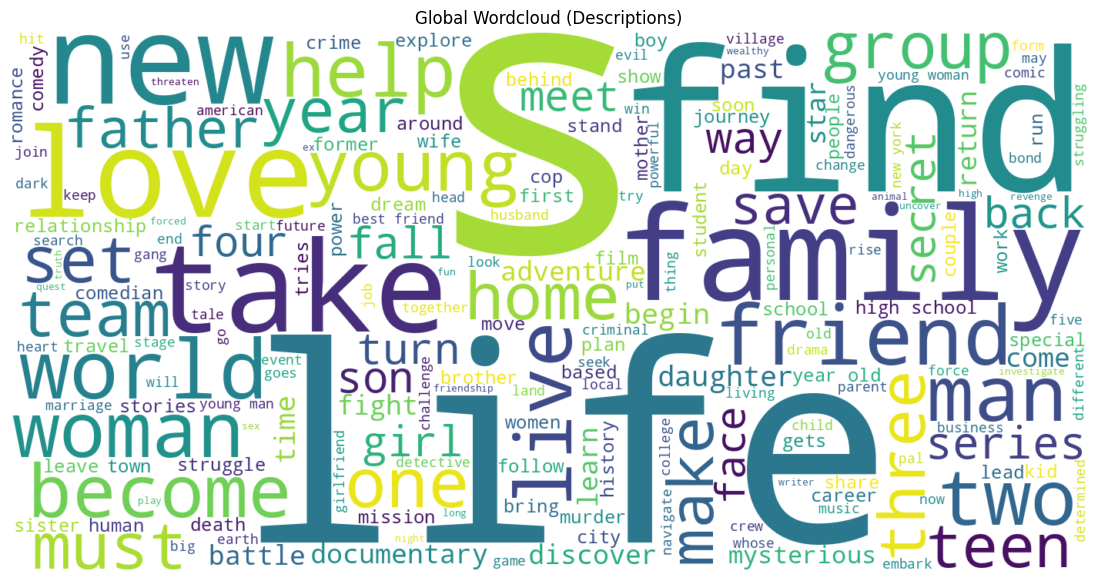

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# GLOBAL WORDCLOUD
text_all = " ".join(df['desc_clean'].tolist())
wc_all = WordCloud(width=1400, height=700, background_color='white').generate(text_all)

plt.figure(figsize=(14,7))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("Global Wordcloud (Descriptions)")
plt.savefig("wordcloud_global.png", dpi=150)
plt.show()     # <= THIS makes it visible in your notebook



In [ ]:
import shutil
shutil.make_archive('tp', 'zip', '/kaggle/working/text_plots')

'/kaggle/working/tp.zip'

In [ ]:
def sent_bucket(x):
    if x > 0.1: return "pos"
    if x < -0.1: return "neg"
    return "neu"

df["sent_class"] = df["sentiment"].apply(sent_bucket)

In [ ]:
# count of each sentiment class
cnt = df['sent_class'].value_counts().reset_index()
cnt.columns = ['sent_class','count']

import plotly.express as px

fig_sent_pie = px.pie(
    cnt,
    names='sent_class',
    values='count',
    title='overall sentiment class share'
)
fig_sent_pie.show()
